In [1]:
#!pip install spectral-cube
#!pip install astroquery
#!pip install reproject
!pip install astropy pandas

In [2]:
import glob #importing glob library
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import numpy as np

import astropy
import astropy.units as u
from astropy.utils.data import download_file
from astropy.io import fits  # We use fits to open the actual data file
from astropy.utils import data
from astropy.wcs import wcs
from astropy.coordinates import SkyCoord
from astropy.time import Time
import pandas as pd

import ipywidgets as widgets
from IPython.display import display
import os

In [3]:
fits_files = glob.glob('C:/Users/jules/OneDrive/Desktop/Research Test Files/*.fit')
fits_files

['C:/Users/jules/OneDrive/Desktop/Research Test Files\\lab2-001.fit',
 'C:/Users/jules/OneDrive/Desktop/Research Test Files\\lab2-002.fit',
 'C:/Users/jules/OneDrive/Desktop/Research Test Files\\lab2-003.fit',
 'C:/Users/jules/OneDrive/Desktop/Research Test Files\\lab2-004.fit',
 'C:/Users/jules/OneDrive/Desktop/Research Test Files\\lab2-005.fit',
 'C:/Users/jules/OneDrive/Desktop/Research Test Files\\lab2-006.fit',
 'C:/Users/jules/OneDrive/Desktop/Research Test Files\\lab2-007.fit',
 'C:/Users/jules/OneDrive/Desktop/Research Test Files\\lab2-008.fit',
 'C:/Users/jules/OneDrive/Desktop/Research Test Files\\lab2-009.fit',
 'C:/Users/jules/OneDrive/Desktop/Research Test Files\\lab2-010.fit']

Filename: C:/Users/jules/OneDrive/Desktop/Research Test Files\lab2-001.fit
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      42   (512, 512)   int16 (rescales to uint16)   
None
SIMPLE  =                    T                                                  
BITPIX  =                   16 /8 unsigned int, 16 & 32 int, -32 & -64 real     
NAXIS   =                    2 /number of axes                                  
NAXIS1  =                  512 /fastest changing axis                           
NAXIS2  =                  512 /next to fastest changing axis                   
BSCALE  =   1.0000000000000000 /physical = BZERO + BSCALE*array_value           
BZERO   =   32768.000000000000 /physical = BZERO + BSCALE*array_value           
DATE-OBS= '2018-03-20T01:47:42' /YYYY-MM-DDThh:mm:ss observation start, UT      
EXPTIME =   90.000000000000000 /Exposure time in seconds                        
EXPOSURE=   90.000000000000000 /Exposure tim

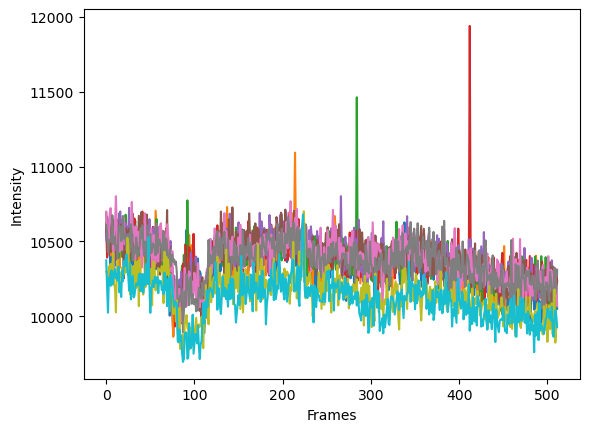

In [4]:
for i in range(0, len(fits_files)):
    hdul = fits.open(fits_files[i])
    print(hdul.info())
    data = hdul[0].data
    print(repr(hdul[0].header))
    print(data[i])
    plt.plot(data[i])
    plt.xlabel('Frames')
    plt.ylabel('Intensity')

In [5]:
cube = np.zeros((len(fits_files),512,512))

In [14]:
for i, fn in enumerate(fits_files):
    hdu = fits.open(fn)
    data = hdu[0].data[:,:]
    cube[i,:,:] = data
    hdu.close()

hdu_new = fits.PrimaryHDU(cube)
hdu_new.writeto('cube.fits', overwrite=True)

PermissionError: [WinError 32] The process cannot access the file because it is being used by another process: 'cube.fits'

In [7]:
hdu_cube = fits.open('cube.fits', memmap=False, overwrite = True)
print(hdu_cube.info())
data = hdu_cube[0].data
print(data)
hdu_cube.close

Filename: cube.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       7   (512, 512, 10)   float64   
None
[[[10594. 10488. 10544. ... 10283. 10184. 10049.]
  [10553. 10535. 10468. ... 10035. 10107. 10054.]
  [10662. 10294. 10611. ... 10039. 10245. 10027.]
  ...
  [10731. 10739. 10729. ... 10504. 10444. 10639.]
  [11070. 10627. 10714. ... 10681. 10499. 10685.]
  [10871. 10786. 10546. ... 10546. 10642. 10630.]]

 [[10619. 10686. 10433. ... 10292. 10197. 10162.]
  [10602. 10510. 10411. ... 10224. 10156. 10090.]
  [10751. 10397. 10669. ... 10237. 10294. 10152.]
  ...
  [10757. 10693. 10755. ... 10674. 10738. 10665.]
  [10702. 10797. 10635. ... 10597. 10576. 10654.]
  [10718. 10916. 10654. ... 10437. 10718. 10698.]]

 [[10531. 10458. 10546. ... 10094. 10047. 10286.]
  [10534. 10686. 10366. ... 10157. 10167. 10032.]
  [10621. 10483. 10429. ... 10001. 10199. 10297.]
  ...
  [10906. 10774. 10646. ... 10716. 10770. 10777.]
  [10940. 10757. 1077

<bound method HDUList.close of [<astropy.io.fits.hdu.image.PrimaryHDU object at 0x000001C74AE99E50>]>

In [37]:
def file_by_date (directory, return_type='both'):
    fits_date = []
    norm_fits = []

    for filename in os.listdir(directory):
        if filename.endswith(('.fits', '.fit')):
            file_path = os.path.join(directory, filename)

        try:
            with fits.open(file_path) as hdul_date:
                date = hdul_date[0].header['DATE-OBS']
            
            fits_date.append({
                'File Name': filename,
                'Date': date,
                'Location': directory
            })
            
        except (KeyError, OSError) as e: 
            print(f"Skipping {filename}: {e}")

        fits_date.sort(key=lambda x: x['Date'])

    for item in fits_date:
        if item['File Name'].endswith(('fit', 'fits')):
            full_path = os.path.join(item['Location'], item['File Name'])

        try:
            with fits.open(full_path) as hdu_fits:
                data_org = hdu_fits[0].data
                data_max = np.max(data_org)
                data_norm = data_org / data_max
                norm_fits.append(data_norm)
                
            for i, data_array in enumerate(norm_fits):
                cube[i,:,:] = data_array

        except (KeyError, OSError) as e: 
            print(f"Skipping {item['File Name']}: {e}")

    hdu_norm_new = fits.PrimaryHDU(cube)
    hdu_norm_new.writeto('cube_norm.fits', overwrite=True)

    cube_norm = fits.open('cube_norm.fits', memmap = False) 
    #cube_norm_info = cube_norm.info()
    cube_norm_data = cube_norm[0].data


    if return_type.lower() == 'cube':
        return cube_norm_data
    elif return_type.lower() == 'dict':
        return fits_date
    else:
        return cube_norm_data, fits_date
    

fits_dict = file_by_date('C:/Users/jules/OneDrive/Desktop/Research Test Files/', return_type='dict')
cube_norm_fits = file_by_date('C:/Users/jules/OneDrive/Desktop/Research Test Files/', return_type='cube')

print(cube_norm_fits)

[[[0.20949594 0.20739979 0.20850719 ... 0.20334592 0.2013882  0.19871858]
  [0.20868516 0.20832921 0.20700429 ... 0.19844173 0.19986553 0.19881746]
  [0.21084063 0.20356345 0.20983211 ... 0.19852083 0.20259447 0.19828353]
  ...
  [0.21220511 0.21236331 0.21216556 ... 0.20771619 0.20652969 0.21038581]
  [0.21890882 0.21014851 0.21186893 ... 0.21121636 0.20761731 0.21129546]
  [0.2149736  0.21329273 0.20854674 ... 0.20854674 0.21044513 0.21020783]]

 [[0.18078894 0.18192962 0.17762228 ... 0.17522175 0.17360437 0.1730085 ]
  [0.18049951 0.17893321 0.17724773 ... 0.17406405 0.17290635 0.17178269]
  [0.18303625 0.17700938 0.18164019 ... 0.17428537 0.1752558  0.17283825]
  ...
  [0.1831384  0.18204879 0.18310435 ... 0.18172532 0.18281492 0.18157209]
  [0.18220202 0.1838194  0.18106134 ... 0.18041439 0.18005686 0.18138482]
  [0.18247442 0.18584538 0.18138482 ... 0.17769038 0.18247442 0.18213392]]

 [[0.17644891 0.17522578 0.17670023 ... 0.16912689 0.16833939 0.17234388]
  [0.17649917 0.179045

In [19]:
fits_dict

[{'File Name': 'lab2-001.fit',
  'Date': '2018-03-20T01:47:42',
  'Location': 'C:/Users/jules/OneDrive/Desktop/Research Test Files/'},
 {'File Name': 'lab2-002.fit',
  'Date': '2018-03-20T01:49:14',
  'Location': 'C:/Users/jules/OneDrive/Desktop/Research Test Files/'},
 {'File Name': 'lab2-003.fit',
  'Date': '2018-03-20T01:50:46',
  'Location': 'C:/Users/jules/OneDrive/Desktop/Research Test Files/'},
 {'File Name': 'lab2-004.fit',
  'Date': '2018-03-20T01:52:18',
  'Location': 'C:/Users/jules/OneDrive/Desktop/Research Test Files/'},
 {'File Name': 'lab2-005.fit',
  'Date': '2018-03-20T01:53:51',
  'Location': 'C:/Users/jules/OneDrive/Desktop/Research Test Files/'},
 {'File Name': 'lab2-006.fit',
  'Date': '2018-03-20T01:55:23',
  'Location': 'C:/Users/jules/OneDrive/Desktop/Research Test Files/'},
 {'File Name': 'lab2-007.fit',
  'Date': '2018-03-20T01:56:55',
  'Location': 'C:/Users/jules/OneDrive/Desktop/Research Test Files/'},
 {'File Name': 'lab2-008.fit',
  'Date': '2018-03-20T01

In [24]:
file_select = widgets.Select(
    options=[item['File Name'] for item in fits_dict],
    description='Display:',
    disabled=False
)

In [25]:
def norm_fits(selected_file):
    hdul_norm = fits.open(selected_file)
    data_org = hdul_norm[0].data
    data_max = np.max(hdul_norm[0].data)
    data_norm = data_org / data_max
    hdul_norm.close()
    return data_norm

In [52]:
def fits_plot(data, filename):
    plt.figure(figsize=(12, 6))
    plt.imshow(data, cmap='gray', origin='lower')
    plt.colorbar(label='Intensity')
    plt.title(f'data from {fits_dict[0]['File Name']}')
    #plt.xlabel('Frames')
    #plt.ylabel('Normalized Intensity')
    plt.show()

In [53]:
def interactive_handler(selected_file):
    file_location = fits_dict[0]['Location']
    full_path = os.path.join(file_location, selected_file)
    
    normalized_data = norm_fits(full_path)
    fits_plot(normalized_data, full_path)

widgets.interactive(interactive_handler, selected_file=file_select)

interactive(children=(Select(description='Display:', index=9, options=('lab2-001.fit', 'lab2-002.fit', 'lab2-0…

Filename: C:/Users/jules/OneDrive/Desktop/Research Test Files/lab2-001.fit
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      42   (512, 512)   int16 (rescales to uint16)   
None
Filename: C:/Users/jules/OneDrive/Desktop/Research Test Files/lab2-002.fit
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      42   (512, 512)   int16 (rescales to uint16)   
None
Filename: C:/Users/jules/OneDrive/Desktop/Research Test Files/lab2-003.fit
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      42   (512, 512)   int16 (rescales to uint16)   
None
Filename: C:/Users/jules/OneDrive/Desktop/Research Test Files/lab2-004.fit
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      42   (512, 512)   int16 (rescales to uint16)   
None
Filename: C:/Users/jules/OneDrive/Desktop/Research Test Files/lab2-005.fit
No.    Name      

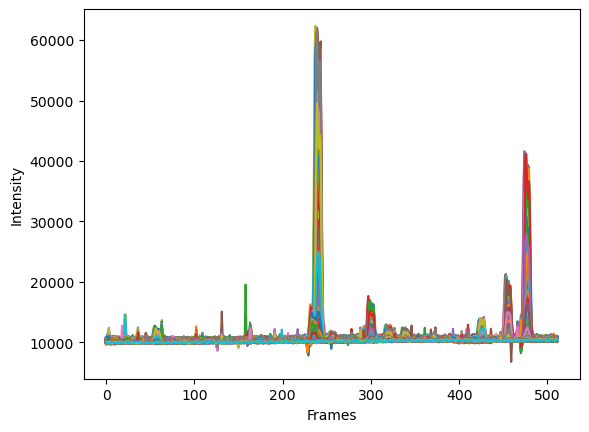

In [21]:
for item in fits_dict:
    full_path = os.path.join(item['Location'], item['File Name'])
    hdul = fits.open(full_path)
    print(hdul.info())
    data = hdul[0].data
    #print(repr(hdul[0].header))
    #print(data)
    plt.plot(data)
    plt.xlabel('Frames')
    plt.ylabel('Intensity')